### Template Matching


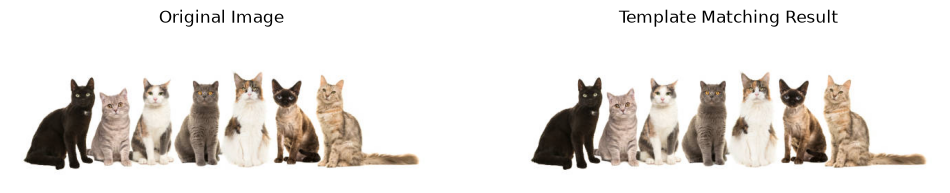

In [1]:
import cv2
import matplotlib.pyplot as plt

# Load images
image = cv2.imread("Images/scene.jpg")
template = cv2.imread("Images/Template.jpg")

# Convert to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
template_gray = cv2.cvtColor(template, cv2.COLOR_BGR2GRAY)

# Template Matching
result = cv2.matchTemplate(
    gray,
    template_gray,
    cv2.TM_CCOEFF_NORMED
)

# Find best location
min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(result)

# Template size
h, w = template_gray.shape

# Draw rectangle
top_left = max_loc
bottom_right = (top_left[0] + w, top_left[1] + h)

output = image.copy()

cv2.rectangle(
    output,
    top_left,
    bottom_right,
    (0,255,0),
    3
)

# Display

plt.figure(figsize=(12,6))

plt.subplot(121)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")

plt.subplot(122)
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title("Template Matching Result")
plt.axis("off")

plt.show()

### ORB Feature Detection + BFMatcher

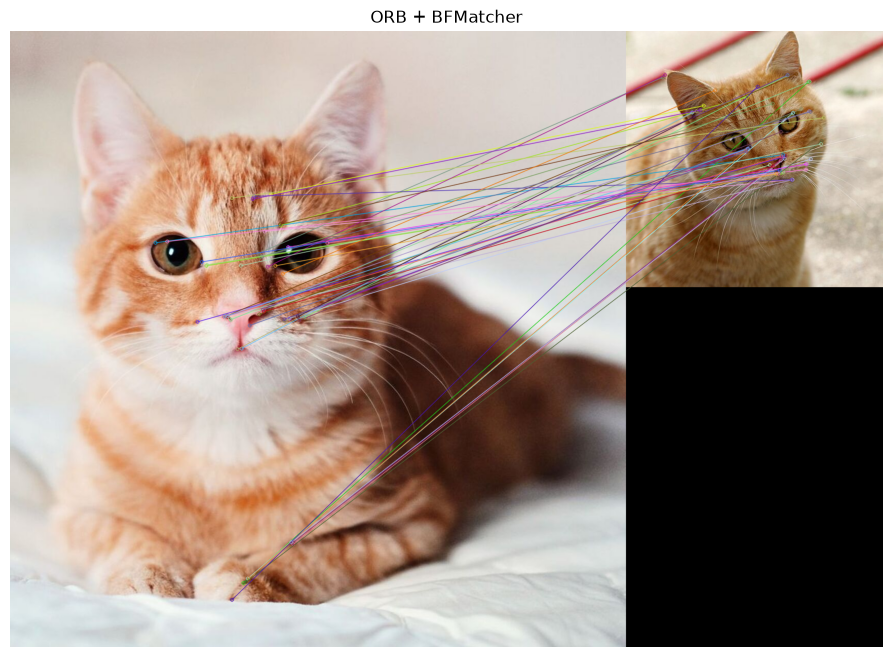

In [ ]:
import cv2
import matplotlib.pyplot as plt

# Load images
img1 = cv2.imread("Images/Image1.jpg")
img2 = cv2.imread("Images/Image2.jpg")

gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

# ORB detector
orb = cv2.ORB_create(nfeatures=1000)

kp1, des1 = orb.detectAndCompute(gray1,None)
kp2, des2 = orb.detectAndCompute(gray2,None)

# BF Matcher
bf = cv2.BFMatcher(
    cv2.NORM_HAMMING,
    crossCheck=True
)

matches = bf.match(des1, des2)

# Sort matches
matches = sorted(matches, key=lambda x:x.distance)

matched = cv2.drawMatches(
    img1,                           # Input image 1
    kp1,                            # Keypoints from image 1
    img2,                           # Input image 2
    kp2,                            # Keypoints from image 2
    matches[:50],                   # Draw the first 50 matches
    None,                           # Output image (if None, a new image is created)
    flags=2                         # Flags for drawing the matches (2 means draw only the matched keypoints)
)

plt.figure(figsize=(18,8))
plt.imshow(cv2.cvtColor(matched,cv2.COLOR_BGR2RGB))
plt.title("ORB + BFMatcher")
plt.axis("off")
plt.show()

### SIFT + BFMatcher

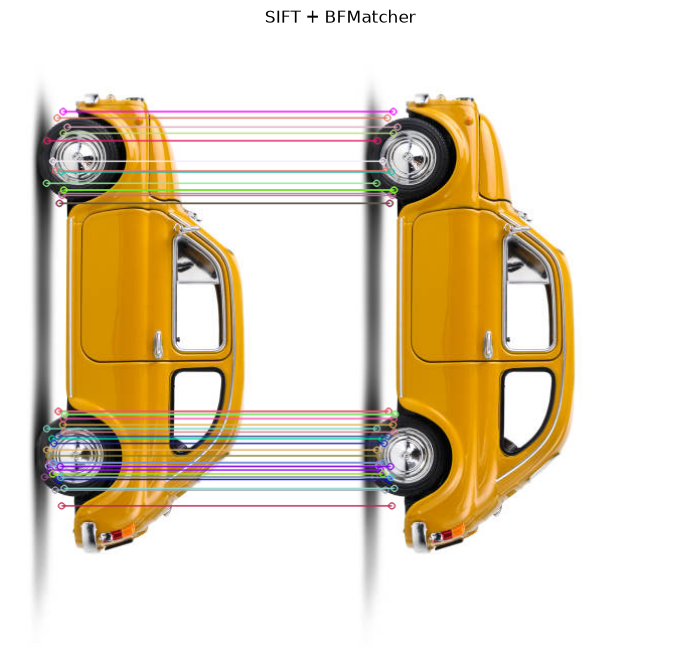

In [3]:
import cv2
import matplotlib.pyplot as plt

img1 = cv2.imread("Images/object.jpg")
img2 = cv2.imread("Images/object_rotated.jpg")

gray1 = cv2.cvtColor(img1,cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2,cv2.COLOR_BGR2GRAY)

# SIFT Detector
sift = cv2.SIFT_create()

kp1, des1 = sift.detectAndCompute(gray1,None)
kp2, des2 = sift.detectAndCompute(gray2,None)

# BF Matcher
bf = cv2.BFMatcher()

matches = bf.match(des1,des2)

matches = sorted(matches,key=lambda x:x.distance)

result = cv2.drawMatches(
    img1,
    kp1,
    img2,
    kp2,
    matches[:40],
    None,
    flags=2
)

plt.figure(figsize=(18,8))
plt.imshow(cv2.cvtColor(result,cv2.COLOR_BGR2RGB))
plt.title("SIFT + BFMatcher")
plt.axis("off")
plt.show()

### SIFT + FLANN Matcher

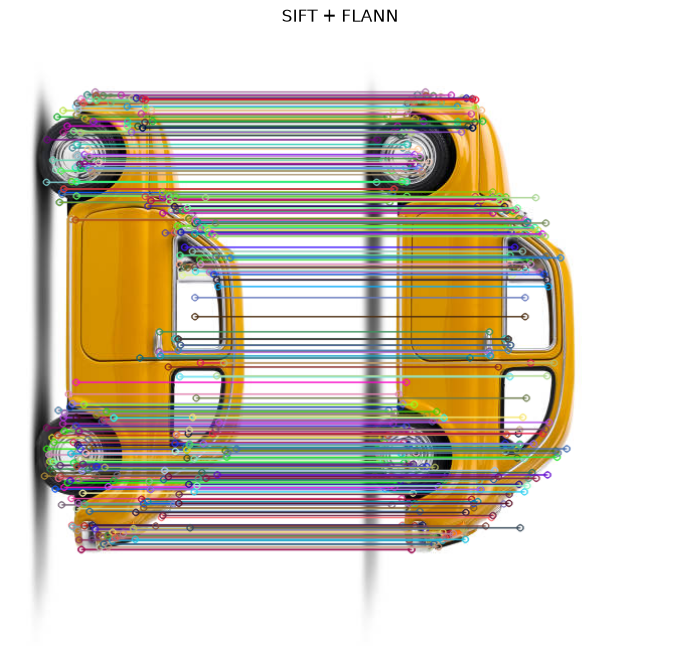

Good Matches: 316


In [4]:
import cv2
import matplotlib.pyplot as plt

img1 = cv2.imread("Images/object.jpg")
img2 = cv2.imread("Images/object_rotated.jpg")

gray1 = cv2.cvtColor(img1,cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2,cv2.COLOR_BGR2GRAY)

# SIFT
sift = cv2.SIFT_create()

kp1, des1 = sift.detectAndCompute(gray1,None)
kp2, des2 = sift.detectAndCompute(gray2,None)

# FLANN Parameters
index_params = dict(
    algorithm=1,
    trees=5
)

search_params = dict(
    checks=50
)

flann = cv2.FlannBasedMatcher(
    index_params,
    search_params
)

matches = flann.knnMatch(
    des1,
    des2,
    k=2
)

# Lowe Ratio Test
good = []

for m,n in matches:
    if m.distance < 0.75*n.distance:
        good.append(m)

result = cv2.drawMatches(
    img1,
    kp1,
    img2,
    kp2,
    good,
    None,
    flags=2
)

plt.figure(figsize=(18,8))
plt.imshow(cv2.cvtColor(result,cv2.COLOR_BGR2RGB))
plt.title("SIFT + FLANN")
plt.axis("off")
plt.show()

print("Good Matches:", len(good))

### Display Detected ORB Keypoints

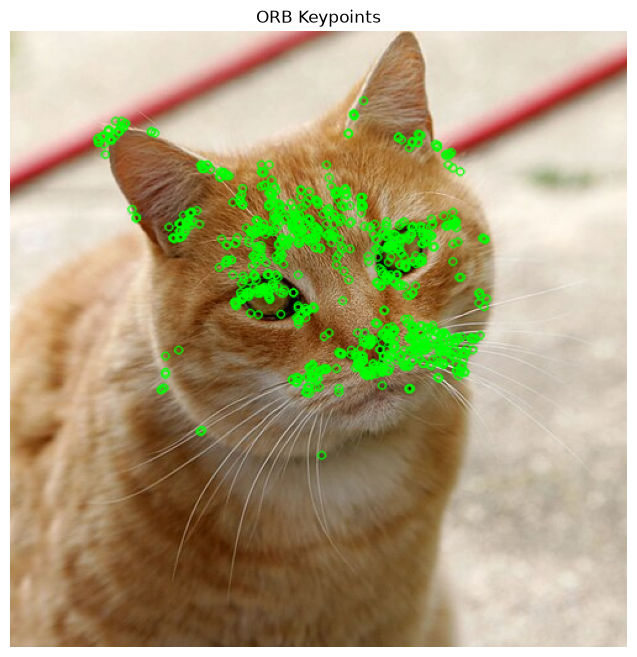

Number of Keypoints: 1000


In [7]:
import cv2
import matplotlib.pyplot as plt

image = cv2.imread("Images/Image2.jpg")
gray = cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)

orb = cv2.ORB_create(1000)

keypoints = orb.detect(gray,None)

result = cv2.drawKeypoints(
    image,
    keypoints,
    None,
    color=(0,255,0),
    flags=0
)

plt.figure(figsize=(10,8))
plt.imshow(cv2.cvtColor(result,cv2.COLOR_BGR2RGB))
plt.title("ORB Keypoints")
plt.axis("off")
plt.show()

print("Number of Keypoints:", len(keypoints))

### Compare BFMatcher and FLANN Side-by-Side

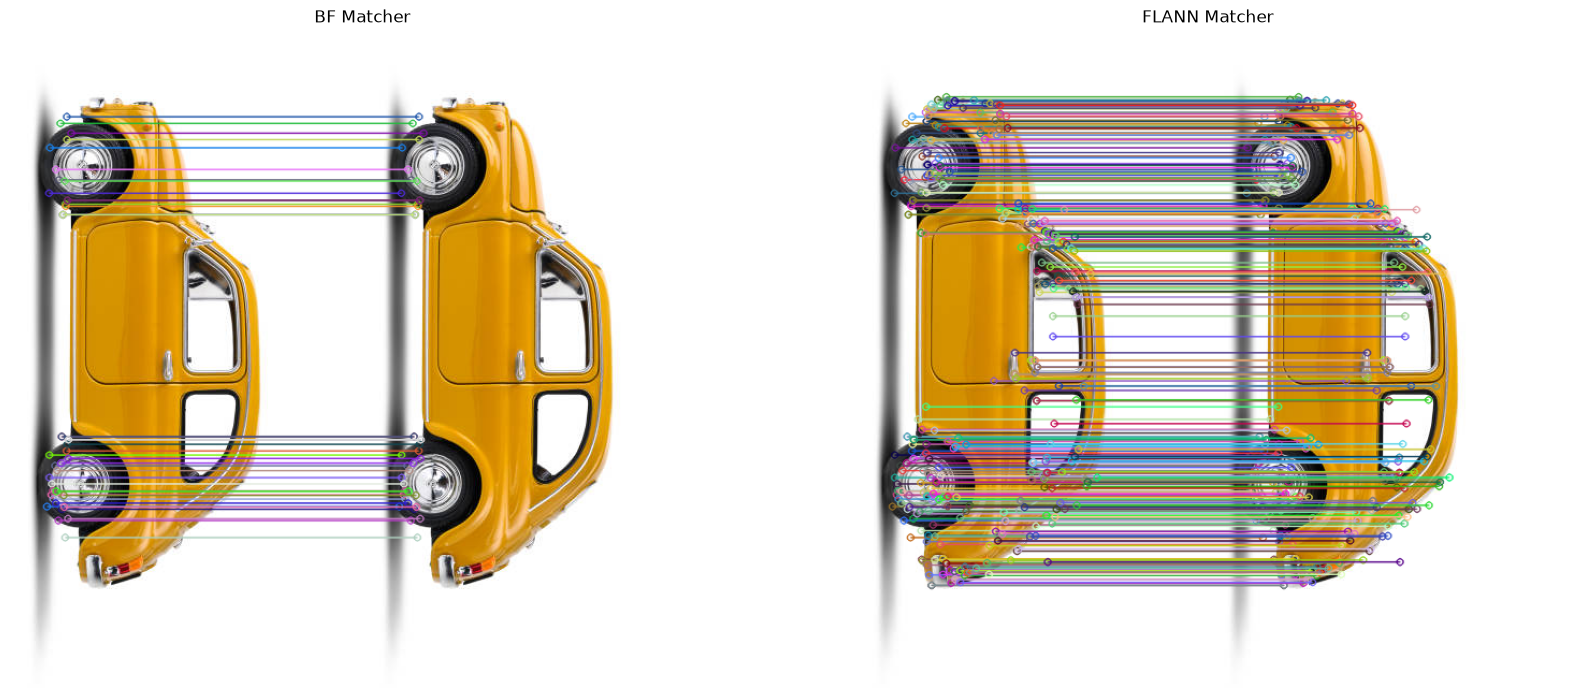

BF Matches : 316
FLANN Good Matches : 316


In [8]:
import cv2
import matplotlib.pyplot as plt

img1 = cv2.imread("Images/object.jpg")
img2 = cv2.imread("Images/object_rotated.jpg")

gray1 = cv2.cvtColor(img1,cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2,cv2.COLOR_BGR2GRAY)

sift = cv2.SIFT_create()

kp1, des1 = sift.detectAndCompute(gray1,None)
kp2, des2 = sift.detectAndCompute(gray2,None)

# BF Matcher
bf = cv2.BFMatcher()
bf_matches = bf.match(des1,des2)
bf_matches = sorted(bf_matches,key=lambda x:x.distance)

bf_img = cv2.drawMatches(
    img1,kp1,
    img2,kp2,
    bf_matches[:40],
    None,
    flags=2
)

# FLANN Matcher
FLANN_INDEX_KDTREE = 1

index_params = dict(
    algorithm=FLANN_INDEX_KDTREE,
    trees=5
)

search_params = dict(checks=50)

flann = cv2.FlannBasedMatcher(index_params,search_params)

matches = flann.knnMatch(des1,des2,k=2)

good=[]

for m,n in matches:
    if m.distance < 0.75*n.distance:
        good.append(m)

flann_img = cv2.drawMatches(
    img1,kp1,
    img2,kp2,
    good,
    None,
    flags=2
)

plt.figure(figsize=(20,10))

plt.subplot(121)
plt.imshow(cv2.cvtColor(bf_img,cv2.COLOR_BGR2RGB))
plt.title("BF Matcher")
plt.axis("off")

plt.subplot(122)
plt.imshow(cv2.cvtColor(flann_img,cv2.COLOR_BGR2RGB))
plt.title("FLANN Matcher")
plt.axis("off")

plt.show()

print("BF Matches :", len(bf_matches))
print("FLANN Good Matches :", len(good))